# Multiple Testing and Selection Bias

**Docker image**: `ml4t`

**Chapter 7: Defining the Learning Task**
**Section Reference**: 7.4 - Search Accounting and Multiple Testing

## Purpose

This notebook addresses the **factor zoo problem**: when testing many signals,
even with proper inference, the "best" will be inflated by selection bias.
We cover FDR control and complexity-aware corrections.

## Learning Objectives

1. Understand why selecting the best IC inflates estimates
2. Apply Benjamini-Hochberg FDR for discovery control
3. Use Rademacher complexity (RAS) for correlated factors
4. Build a practical pipeline: HAC p-values → BH → discoveries

## The Factor Zoo Problem

Harvey, Liu & Zhu (2016) documented 300+ factors published by 2015.
At 5% significance: 300 × 0.05 = 15 false discoveries expected!

Their recommendation: **t > 3.0** (not 2.0) for new factor discovery.

## Prerequisites

- `06_ic_inference` — provides per-factor HAC inference whose p-values feed
  the BH/Holm/Rademacher corrections here.
- Familiarity with the family-wise error rate (FWER) and false discovery
  rate (FDR), and with the Sharpe ratio's distribution under selection.

In [1]:
"""Multiple Testing — Bonferroni, FDR, and deflated Sharpe corrections for strategy evaluation."""

from __future__ import annotations

import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import display
from ml4t.diagnostic.evaluation.stats import (
    benjamini_hochberg_fdr,
    compute_min_trl,
    compute_pbo,
    deflated_sharpe_ratio,
    holm_bonferroni,
    min_trl_fwer,
    multiple_testing_summary,
    rademacher_complexity,
    ras_ic_adjustment,
)
from ml4t.diagnostic.metrics import compute_ic_hac_stats, pooled_ic
from plotly.subplots import make_subplots
from scipy import stats

from data import load_etfs
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
OUTPUT_DIR = Path("07_defining_the_learning_task/output")
N_FACTORS = 100
N_PERIODS = 252
N_ASSETS = 50
N_FIGURE_SIMS = 200
N_RAD_SIMS = 5000
N_FACTORS_ZOO = 300
N_TRUE_ZOO = 15
N_PERIODS_ZOO = 1260
N_ASSETS_ZOO = 100
ETF_START_DATE = "2010-01-01"
N_RAD_ETF = 5000
N_STRATEGIES_DSR = 50
N_DAYS_DSR = 756
N_STRAT_PBO = 20
N_COMBOS_PBO = 50

In [3]:
set_global_seeds(SEED)

## 1. The Selection Bias Problem

When testing N factors and selecting the best:
- **Observed IC**: max(IC₁, IC₂, ..., ICₙ)
- **True IC**: Often much lower

Under the null (all factors are noise), the expected maximum is:

$$E[\max IC] \approx \sqrt{2 \ln N} \times \sigma_{IC}$$

This is the "expected best by chance" - the selection bias.

In [4]:
# Simulate the selection bias problem with synthetic factors
rng = np.random.default_rng(42)

n_factors = N_FACTORS
n_periods = N_PERIODS
n_assets = N_ASSETS

# Generate factors - ALL are noise (no true predictive power)
factor_signals = rng.standard_normal((n_periods, n_assets, n_factors))
forward_returns = rng.standard_normal((n_periods, n_assets)) * 0.02

# Compute IC for each factor
observed_ics = []
ic_series_all = []

for f in range(n_factors):
    ics = []
    for t in range(n_periods):
        ic = pooled_ic(factor_signals[t, :, f], forward_returns[t, :], method="spearman")
        ics.append(ic)

    ic_series_all.append(ics)
    observed_ics.append(np.mean(ics))

observed_ics = np.array(observed_ics)
ic_series_all = np.array(ic_series_all)

In [5]:
# The "best" factor by IC
best_idx = np.argmax(observed_ics)
best_ic = observed_ics[best_idx]

# Expected max under null: sqrt(2 * ln(N)) * std(IC)
# Note: We use the observed IC std as an estimate of sigma_IC
ic_std = np.std(observed_ics)
expected_max_null = np.sqrt(2 * np.log(n_factors)) * ic_std

print(
    pl.DataFrame(
        {
            "metric": [
                "Factors tested",
                "Sample (days)",
                "True IC",
                "IC mean",
                "IC std",
                "IC max (selected)",
                "IC min",
                "E[max] under null",
            ],
            "value": [
                f"{n_factors}",
                f"{n_periods}",
                "0.0000",
                f"{np.mean(observed_ics):.4f}",
                f"{ic_std:.4f}",
                f"{best_ic:.4f}",
                f"{np.min(observed_ics):.4f}",
                f"{expected_max_null:.4f}",
            ],
        }
    )
)

shape: (8, 2)
┌───────────────────┬─────────┐
│ metric            ┆ value   │
│ ---               ┆ ---     │
│ str               ┆ str     │
╞═══════════════════╪═════════╡
│ Factors tested    ┆ 100     │
│ Sample (days)     ┆ 252     │
│ True IC           ┆ 0.0000  │
│ IC mean           ┆ -0.0006 │
│ IC std            ┆ 0.0075  │
│ IC max (selected) ┆ 0.0198  │
│ IC min            ┆ -0.0219 │
│ E[max] under null ┆ 0.0227  │
└───────────────────┴─────────┘


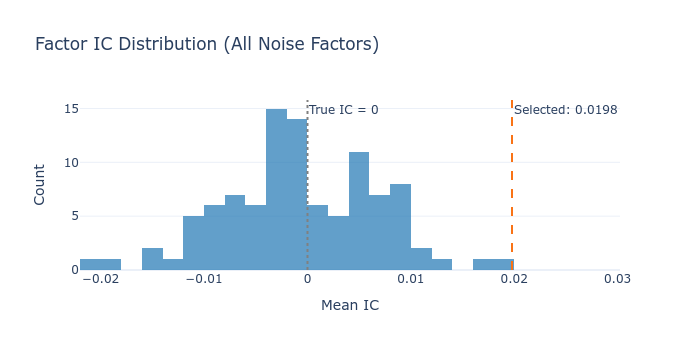

In [6]:
# Visualize selection bias
fig = go.Figure()

fig.add_trace(
    go.Histogram(
        x=observed_ics,
        nbinsx=25,
        name="Factor ICs",
        marker_color="#1f77b4",
        opacity=0.7,
    )
)

fig.add_vline(
    x=best_ic,
    line_dash="dash",
    line_color="#f97316",
    annotation_text=f"Selected: {best_ic:.4f}",
)

fig.add_vline(
    x=0,
    line_dash="dot",
    line_color="gray",
    annotation_text="True IC = 0",
)

fig.update_layout(
    title="Factor IC Distribution (All Noise Factors)",
    xaxis_title="Mean IC",
    yaxis_title="Count",
    template="plotly_white",
    height=350,
)

fig.show()

### Publication Figure Artifact

The book figure for this section reads a compact NumPy artifact so formatting
changes do not rerun the null simulation.

In [7]:


def _vectorized_rank_ic(signals_3d: np.ndarray, returns_2d: np.ndarray) -> np.ndarray:
    sig_ranks = stats.rankdata(signals_3d, axis=1)
    ret_ranks = stats.rankdata(returns_2d, axis=1)
    sig_ranks -= sig_ranks.mean(axis=1, keepdims=True)
    ret_ranks -= ret_ranks.mean(axis=1, keepdims=True)
    numer = (sig_ranks * ret_ranks[:, :, np.newaxis]).sum(axis=1)
    denom_sig = np.sqrt((sig_ranks**2).sum(axis=1))
    denom_ret = np.sqrt((ret_ranks**2).sum(axis=1, keepdims=True))
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.nan_to_num(numer / (denom_sig * denom_ret), nan=0.0).mean(axis=0)


def _vectorized_ic_with_pvals(
    signals_3d: np.ndarray, returns_2d: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    sig_ranks = stats.rankdata(signals_3d, axis=1)
    ret_ranks = stats.rankdata(returns_2d, axis=1)
    sig_ranks -= sig_ranks.mean(axis=1, keepdims=True)
    ret_ranks -= ret_ranks.mean(axis=1, keepdims=True)
    numer = (sig_ranks * ret_ranks[:, :, np.newaxis]).sum(axis=1)
    denom_sig = np.sqrt((sig_ranks**2).sum(axis=1))
    denom_ret = np.sqrt((ret_ranks**2).sum(axis=1, keepdims=True))
    with np.errstate(divide="ignore", invalid="ignore"):
        ics = np.nan_to_num(numer / (denom_sig * denom_ret), nan=0.0)
    mean_ics = ics.mean(axis=0)
    se_ics = ics.std(axis=0) / np.sqrt(ics.shape[0])
    with np.errstate(divide="ignore", invalid="ignore"):
        t_stats = np.nan_to_num(mean_ics / se_ics, nan=0.0)
    p_values_figure = 2 * (1 - stats.norm.cdf(np.abs(t_stats)))
    return mean_ics, p_values_figure


def write_figure_7_6_artifact() -> Path:
    figure_rng = np.random.default_rng(SEED)
    figure_signals = figure_rng.standard_normal((N_PERIODS, N_ASSETS, N_FACTORS))
    figure_returns = figure_rng.standard_normal((N_PERIODS, N_ASSETS)) * 0.02
    figure_observed_ics = _vectorized_rank_ic(figure_signals, figure_returns)
    figure_best_ic = np.max(figure_observed_ics)
    figure_expected_max = np.sqrt(2 * np.log(N_FACTORS)) * np.std(figure_observed_ics)

    best_ics = np.empty(N_FIGURE_SIMS)
    n_naive_reject = np.empty(N_FIGURE_SIMS, dtype=int)
    n_bh_reject = np.empty(N_FIGURE_SIMS, dtype=int)
    bh_threshold = np.arange(1, N_FACTORS + 1) / N_FACTORS * 0.05

    for sim in range(N_FIGURE_SIMS):
        sim_signals = figure_rng.standard_normal((N_PERIODS, N_ASSETS, N_FACTORS))
        sim_returns = figure_rng.standard_normal((N_PERIODS, N_ASSETS)) * 0.02
        sim_ics, sim_pvals = _vectorized_ic_with_pvals(sim_signals, sim_returns)
        best_ics[sim] = np.max(sim_ics)
        n_naive_reject[sim] = int(np.sum(sim_pvals < 0.05))
        sorted_p = np.sort(sim_pvals)
        reject_idx = np.where(sorted_p <= bh_threshold)[0]
        n_bh_reject[sim] = int(reject_idx[-1] + 1) if len(reject_idx) else 0

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    artifact = OUTPUT_DIR / "figure_7_6_multiple_testing.npz"
    np.savez(
        artifact,
        observed_ics=figure_observed_ics,
        best_ic=figure_best_ic,
        expected_max=figure_expected_max,
        best_ics=best_ics,
        n_naive_reject=n_naive_reject,
        n_bh_reject=n_bh_reject,
        n_factors=N_FACTORS,
        n_sims=N_FIGURE_SIMS,
    )
    return artifact


figure_7_6_artifact = write_figure_7_6_artifact()
print(f"Wrote publication figure artifact: {figure_7_6_artifact}")

Wrote publication figure artifact: 07_defining_the_learning_task/output/figure_7_6_multiple_testing.npz


## 2. Benjamini-Hochberg FDR Control

**False Discovery Rate (FDR)** controls the expected proportion of false
discoveries among rejections:

$$FDR = E\left[\frac{\text{False Positives}}{\text{All Discoveries}}\right]$$

The BH procedure:
1. Sort p-values: p₍₁₎ ≤ p₍₂₎ ≤ ... ≤ p₍ₙ₎
2. Find largest k where p₍ₖ₎ ≤ (k/n) × α
3. Reject hypotheses 1, 2, ..., k

In [8]:
# Compute HAC-adjusted p-values for each factor
# IMPORTANT: Use HAC p-values, not naive t-stats
p_values = []
for f in range(n_factors):
    hac_stats = compute_ic_hac_stats(ic_series_all[f])
    p_values.append(hac_stats["p_value"])

p_values = np.array(p_values)

# Apply Benjamini-Hochberg
bh_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)

# Count discoveries
naive_significant = np.sum(p_values < 0.05)
bh_significant = np.sum(bh_result["rejected"])

print(
    pl.DataFrame(
        {
            "method": ["Naive (p < 0.05)", "BH-FDR (alpha=0.05)"],
            "discoveries": [naive_significant, bh_significant],
            "expected_fp": [int(n_factors * 0.05), 0],
        }
    )
)

shape: (2, 3)
┌─────────────────────┬─────────────┬─────────────┐
│ method              ┆ discoveries ┆ expected_fp │
│ ---                 ┆ ---         ┆ ---         │
│ str                 ┆ i64         ┆ i64         │
╞═════════════════════╪═════════════╪═════════════╡
│ Naive (p < 0.05)    ┆ 3           ┆ 5           │
│ BH-FDR (alpha=0.05) ┆ 0           ┆ 0           │
└─────────────────────┴─────────────┴─────────────┘


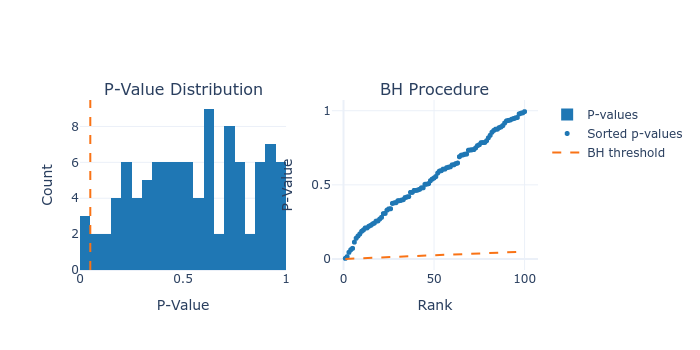

In [9]:
# Visualize BH procedure
fig = make_subplots(rows=1, cols=2, subplot_titles=["P-Value Distribution", "BH Procedure"])

# P-value histogram (should be uniform under null)
fig.add_trace(
    go.Histogram(
        x=p_values,
        nbinsx=20,
        name="P-values",
        marker_color="#1f77b4",
    ),
    row=1,
    col=1,
)

fig.add_vline(x=0.05, line_dash="dash", line_color="#f97316", row=1, col=1)

# BH procedure visualization
sorted_idx = np.argsort(p_values)
sorted_p = p_values[sorted_idx]
ranks = np.arange(1, n_factors + 1)
bh_threshold = (ranks / n_factors) * 0.05

fig.add_trace(
    go.Scatter(
        x=ranks,
        y=sorted_p,
        mode="markers",
        name="Sorted p-values",
        marker=dict(size=5, color="#1f77b4"),
    ),
    row=1,
    col=2,
)

fig.add_trace(
    go.Scatter(
        x=ranks,
        y=bh_threshold,
        mode="lines",
        name="BH threshold",
        line=dict(dash="dash", color="#f97316"),
    ),
    row=1,
    col=2,
)

fig.update_layout(height=350, template="plotly_white")
fig.update_xaxes(title_text="P-Value", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_xaxes(title_text="Rank", row=1, col=2)
fig.update_yaxes(title_text="P-Value", row=1, col=2)

fig.show()

### 2.1 Holm-Bonferroni FWER Control

BH controls **FDR** (the expected proportion of false discoveries among rejections).
Holm-Bonferroni controls **FWER** (the probability of making *any* false discovery).

Use FWER when even one false positive is unacceptable — e.g., deploying a new
strategy that incurs real capital risk.

In [10]:
# Apply Holm-Bonferroni to the same p-values
holm_result = holm_bonferroni(p_values, alpha=0.05)
holm_significant = np.sum(holm_result["rejected"])

print(
    pl.DataFrame(
        {
            "method": ["Naive (p < 0.05)", "BH-FDR (alpha=0.05)", "Holm-Bonferroni (alpha=0.05)"],
            "discoveries": [naive_significant, bh_significant, holm_significant],
            "controls": ["Nothing", "FDR", "FWER"],
            "guarantee": [
                "None",
                "E[FP/discoveries] <= alpha",
                "P(any FP) <= alpha",
            ],
        }
    )
)

shape: (3, 4)
┌──────────────────────────────┬─────────────┬──────────┬────────────────────────────┐
│ method                       ┆ discoveries ┆ controls ┆ guarantee                  │
│ ---                          ┆ ---         ┆ ---      ┆ ---                        │
│ str                          ┆ i64         ┆ str      ┆ str                        │
╞══════════════════════════════╪═════════════╪══════════╪════════════════════════════╡
│ Naive (p < 0.05)             ┆ 3           ┆ Nothing  ┆ None                       │
│ BH-FDR (alpha=0.05)          ┆ 0           ┆ FDR      ┆ E[FP/discoveries] <= alpha │
│ Holm-Bonferroni (alpha=0.05) ┆ 0           ┆ FWER     ┆ P(any FP) <= alpha         │
└──────────────────────────────┴─────────────┴──────────┴────────────────────────────┘


## 3. Rademacher Complexity (RAS)

When factors are correlated, Rademacher complexity provides a sharper bound
than assuming independence. The RAS (Rademacher Anti-Serum) adjustment
accounts for the actual complexity of the hypothesis class.

Key insight: Testing 100 variants of the same factor is less risky than
testing 100 truly independent factors.

In [11]:
# Compute Rademacher complexity
ic_matrix = ic_series_all.T  # Shape: (T, N)
ic_matrix_norm = (ic_matrix - np.mean(ic_matrix, axis=0)) / np.std(ic_matrix, axis=0, ddof=1)

n_rad_sims = N_RAD_SIMS
R_hat = rademacher_complexity(ic_matrix_norm, n_simulations=n_rad_sims, random_state=42)

# Massart's bound (theoretical max for independent factors)
massart_bound = np.sqrt(2 * np.log(n_factors) / n_periods)

print(
    pl.DataFrame(
        {
            "metric": ["Empirical R-hat", "Massart bound", "Ratio"],
            "value": [f"{R_hat:.4f}", f"{massart_bound:.4f}", f"{R_hat / massart_bound:.1%}"],
        }
    )
)

shape: (3, 2)
┌─────────────────┬────────┐
│ metric          ┆ value  │
│ ---             ┆ ---    │
│ str             ┆ str    │
╞═════════════════╪════════╡
│ Empirical R-hat ┆ 0.1571 │
│ Massart bound   ┆ 0.1912 │
│ Ratio           ┆ 82.2%  │
└─────────────────┴────────┘


A ratio near 100% means factors are nearly independent — the full multiple-testing
penalty applies. A ratio well below 100% signals correlation among candidates,
meaning the effective hypothesis count is lower than the nominal count.

In [12]:
# Apply RAS adjustment
adjusted_ics = ras_ic_adjustment(
    observed_ic=observed_ics,
    complexity=R_hat,
    n_samples=n_periods,
    delta=0.05,
    kappa=0.5,
)

# Compare
n_significant_raw = np.sum(np.abs(observed_ics) > 0.01)
n_significant_ras = np.sum(np.abs(adjusted_ics) > 0.01)

print(
    pl.DataFrame(
        {
            "metric": [
                "|IC| > 0.01 before RAS",
                "|IC| > 0.01 after RAS",
                "Best observed IC",
                "Best adjusted IC",
                "Shrinkage",
            ],
            "value": [
                f"{n_significant_raw}/{n_factors}",
                f"{n_significant_ras}/{n_factors}",
                f"{best_ic:.4f}",
                f"{adjusted_ics[best_idx]:.4f}",
                f"{(best_ic - adjusted_ics[best_idx]) / best_ic:.0%}",
            ],
        }
    )
)

shape: (5, 2)
┌────────────────────────┬─────────┐
│ metric                 ┆ value   │
│ ---                    ┆ ---     │
│ str                    ┆ str     │
╞════════════════════════╪═════════╡
│ |IC| > 0.01 before RAS ┆ 15/100  │
│ |IC| > 0.01 after RAS  ┆ 100/100 │
│ Best observed IC       ┆ 0.0198  │
│ Best adjusted IC       ┆ -0.4155 │
│ Shrinkage              ┆ 2200%   │
└────────────────────────┴─────────┘


## 4. Harvey et al. (2016) Thresholds

Based on the "factor zoo" of 300+ published factors, Harvey et al. recommend
stricter thresholds for new factor discovery:

| Context | Threshold | Rationale |
|---------|-----------|-----------|
| Traditional | t > 2.0 | 5% significance, single test |
| Modern | t > 3.0 | Accounts for ~300 prior factors |
| Strict | t > 3.5 | For new factor discovery papers |

In [13]:
# Simulate factor zoo scenario
n_factors_zoo = N_FACTORS_ZOO
n_true = N_TRUE_ZOO
n_periods_zoo = N_PERIODS_ZOO
n_assets_zoo = N_ASSETS_ZOO

true_ic = 0.03

print(
    f"Factor zoo: {n_factors_zoo} factors ({n_true} true, IC={true_ic}), "
    f"{n_periods_zoo} days ({n_periods_zoo // 252} years), {n_assets_zoo} assets"
)

Factor zoo: 300 factors (15 true, IC=0.03), 1260 days (5 years), 100 assets


In [14]:
# Generate factor signals and returns
rng_zoo = np.random.default_rng(123)
factor_signals_zoo = rng_zoo.standard_normal((n_periods_zoo, n_assets_zoo, n_factors_zoo))

# Returns = base noise + contribution from true factors only
base_returns = rng_zoo.standard_normal((n_periods_zoo, n_assets_zoo)) * 0.02
true_signal = factor_signals_zoo[:, :, :n_true].sum(axis=2) * true_ic * 0.01
forward_returns_zoo = base_returns + true_signal

# Compute IC and HAC p-values
zoo_results = []
is_true_factor = np.array([f < n_true for f in range(n_factors_zoo)])

for f in range(n_factors_zoo):
    ics = []
    for t in range(n_periods_zoo):
        ic = pooled_ic(factor_signals_zoo[t, :, f], forward_returns_zoo[t, :], method="spearman")
        ics.append(ic)

    hac = compute_ic_hac_stats(ics)

    zoo_results.append(
        {
            "factor": f"Factor_{f + 1:03d}",
            "mean_ic": np.mean(ics),
            "t_stat_hac": hac["t_stat"],
            "p_value_hac": hac["p_value"],
            "is_true": f < n_true,
        }
    )

zoo_df = pl.DataFrame(zoo_results)

In [15]:
# Apply different thresholds
alpha = 0.05

# Naive: t > 2.0
naive_sig = zoo_df.filter(pl.col("t_stat_hac").abs() > 2.0)
naive_tp = naive_sig.filter(pl.col("is_true")).height
naive_fp = naive_sig.filter(~pl.col("is_true")).height

# Harvey threshold: t > 3.0
harvey_sig = zoo_df.filter(pl.col("t_stat_hac").abs() > 3.0)
harvey_tp = harvey_sig.filter(pl.col("is_true")).height
harvey_fp = harvey_sig.filter(~pl.col("is_true")).height

# BH-FDR
p_values_zoo = zoo_df["p_value_hac"].to_numpy()
bh_zoo = benjamini_hochberg_fdr(p_values_zoo, alpha=0.05, return_details=True)
bh_significant = bh_zoo["rejected"]
bh_tp = np.sum(bh_significant & is_true_factor)
bh_fp = np.sum(bh_significant & ~is_true_factor)

# Holm-Bonferroni (FWER control)
holm_zoo = holm_bonferroni(p_values_zoo, alpha=0.05)
holm_significant_zoo = np.array(holm_zoo["rejected"])
holm_tp = np.sum(holm_significant_zoo & is_true_factor)
holm_fp = np.sum(holm_significant_zoo & ~is_true_factor)


def _fdr(fp, total):
    """Compute realized false discovery rate as false positives / total discoveries."""
    return round(fp / total, 3) if total > 0 else 0.0


methods_data = [
    ("Naive (t > 2.0)", naive_sig.height, naive_tp, naive_fp),
    ("Harvey (t > 3.0)", harvey_sig.height, harvey_tp, harvey_fp),
    ("BH-FDR (alpha=0.05)", int(np.sum(bh_significant)), bh_tp, bh_fp),
    ("Holm-Bonf (alpha=0.05)", int(np.sum(holm_significant_zoo)), holm_tp, holm_fp),
]

print(
    pl.DataFrame(
        {
            "method": [m[0] for m in methods_data],
            "discoveries": [m[1] for m in methods_data],
            "true_pos": [m[2] for m in methods_data],
            "false_pos": [m[3] for m in methods_data],
            "realized_fdr": [_fdr(m[3], m[1]) for m in methods_data],
            "power": [round(m[2] / n_true, 3) for m in methods_data],
        }
    )
)

shape: (4, 6)
┌────────────────────────┬─────────────┬──────────┬───────────┬──────────────┬───────┐
│ method                 ┆ discoveries ┆ true_pos ┆ false_pos ┆ realized_fdr ┆ power │
│ ---                    ┆ ---         ┆ ---      ┆ ---       ┆ ---          ┆ ---   │
│ str                    ┆ i64         ┆ i64      ┆ i64       ┆ f64          ┆ f64   │
╞════════════════════════╪═════════════╪══════════╪═══════════╪══════════════╪═══════╡
│ Naive (t > 2.0)        ┆ 27          ┆ 15       ┆ 12        ┆ 0.444        ┆ 1.0   │
│ Harvey (t > 3.0)       ┆ 16          ┆ 15       ┆ 1         ┆ 0.062        ┆ 1.0   │
│ BH-FDR (alpha=0.05)    ┆ 15          ┆ 15       ┆ 0         ┆ 0.0          ┆ 1.0   │
│ Holm-Bonf (alpha=0.05) ┆ 12          ┆ 12       ┆ 0         ┆ 0.0          ┆ 0.8   │
└────────────────────────┴─────────────┴──────────┴───────────┴──────────────┴───────┘


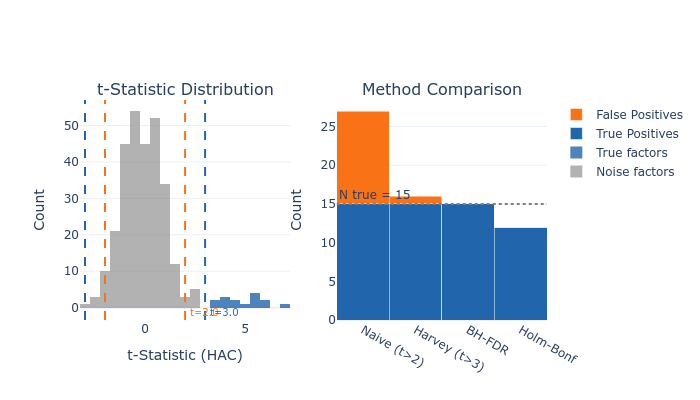

In [16]:
# Visualize factor zoo results
fig = make_subplots(
    rows=1, cols=2, subplot_titles=["t-Statistic Distribution", "Method Comparison"]
)

# t-stat distribution
t_stats = zoo_df["t_stat_hac"].to_numpy()
true_mask = is_true_factor

fig.add_trace(
    go.Histogram(
        x=t_stats[~true_mask],
        name="Noise factors",
        marker_color="gray",
        opacity=0.6,
        nbinsx=30,
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Histogram(
        x=t_stats[true_mask],
        name="True factors",
        marker_color="#2166ac",
        opacity=0.8,
        nbinsx=15,
    ),
    row=1,
    col=1,
)

# Threshold lines with annotations
for thresh, label, color in [(2.0, "t=2.0", "#f97316"), (3.0, "t=3.0", "#2166ac")]:
    for sign in [1, -1]:
        fig.add_vline(x=sign * thresh, line_dash="dash", line_color=color, row=1, col=1)
    fig.add_annotation(
        x=thresh,
        y=1,
        yref="paper",
        text=label,
        showarrow=False,
        font=dict(size=10, color=color),
        xanchor="left",
        yanchor="top",
        xshift=3,
        row=1,
        col=1,
    )

# Method comparison — colorblind-safe blue/orange
methods = ["Naive (t>2)", "Harvey (t>3)", "BH-FDR", "Holm-Bonf"]
tp_counts = [naive_tp, harvey_tp, bh_tp, holm_tp]
fp_counts = [naive_fp, harvey_fp, bh_fp, holm_fp]

fig.add_trace(
    go.Bar(x=methods, y=tp_counts, name="True Positives", marker_color="#2166ac"),
    row=1,
    col=2,
)
fig.add_trace(
    go.Bar(x=methods, y=fp_counts, name="False Positives", marker_color="#f97316"),
    row=1,
    col=2,
)

fig.add_hline(
    y=n_true,
    line_dash="dot",
    line_color="gray",
    row=1,
    col=2,
    annotation_text=f"N true = {n_true}",
    annotation_position="top left",
)

fig.update_layout(height=400, template="plotly_white", barmode="stack")
fig.update_xaxes(title_text="t-Statistic (HAC)", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=2)

fig.show()

## 5. Practical Pipeline

The recommended workflow for evaluating many factors:

1. **Compute HAC-adjusted p-values** for each factor
2. **Apply BH-FDR** to control false discovery rate
3. **Report adjusted p-values** alongside discoveries
4. **Consider RAS** if factors are correlated (e.g., parameter variants)

In [17]:
# Build discovery table
discovery_df = zoo_df.with_columns(
    [
        pl.Series("bh_rejected", bh_zoo["rejected"]),
        pl.Series("adjusted_p", bh_zoo["adjusted_p_values"]),
    ]
)

# Filter to discoveries
discoveries = discovery_df.filter(pl.col("bh_rejected")).sort("mean_ic", descending=True)

print(f"BH-FDR discoveries: {discoveries.height}/{n_factors_zoo} factors")

if discoveries.height > 0:
    print(
        discoveries.select(
            ["factor", "mean_ic", "t_stat_hac", "p_value_hac", "adjusted_p", "is_true"]
        )
    )
else:
    print("No discoveries at α=0.05")
    print("\nTop 5 candidates by IC:")
    print(
        discovery_df.sort("mean_ic", descending=True)
        .head(5)
        .select(["factor", "mean_ic", "t_stat_hac", "p_value_hac", "adjusted_p", "is_true"])
    )

BH-FDR discoveries: 15/300 factors
shape: (15, 6)
┌────────────┬──────────┬────────────┬─────────────┬────────────┬─────────┐
│ factor     ┆ mean_ic  ┆ t_stat_hac ┆ p_value_hac ┆ adjusted_p ┆ is_true │
│ ---        ┆ ---      ┆ ---        ┆ ---         ┆ ---        ┆ ---     │
│ str        ┆ f64      ┆ f64        ┆ f64         ┆ f64        ┆ bool    │
╞════════════╪══════════╪════════════╪═════════════╪════════════╪═════════╡
│ Factor_014 ┆ 0.018992 ┆ 6.756454   ┆ 2.1559e-11  ┆ 6.4676e-9  ┆ true    │
│ Factor_008 ┆ 0.017345 ┆ 5.731662   ┆ 1.2434e-8   ┆ 9.3257e-7  ┆ true    │
│ Factor_013 ┆ 0.016229 ┆ 5.318475   ┆ 1.2372e-7   ┆ 0.000006   ┆ true    │
│ Factor_004 ┆ 0.015919 ┆ 5.874797   ┆ 5.4125e-9   ┆ 5.4125e-7  ┆ true    │
│ Factor_009 ┆ 0.015883 ┆ 5.986213   ┆ 2.7971e-9   ┆ 4.1956e-7  ┆ true    │
│ …          ┆ …        ┆ …          ┆ …           ┆ …          ┆ …       │
│ Factor_005 ┆ 0.01091  ┆ 3.849294   ┆ 0.000124    ┆ 0.00311    ┆ true    │
│ Factor_011 ┆ 0.01061  ┆ 3.728067   ┆

## 5.1 Exploration vs. Confirmation Pass

Section 7.4 recommends splitting evaluation into two passes:

1. **Exploration**: screen all candidates on the first portion of data,
   promote based on fold stability rather than peak performance.
2. **Confirmation**: re-evaluate only promoted candidates on held-out data
   with a reduced comparison set.

The confirmation pass controls FDR more tightly because the search set
shrinks to only the promoted candidates.

In [18]:
# Split zoo data into exploration (first 80%) and confirmation (last 20%)
n_explore = int(n_periods_zoo * 0.8)

explore_signals = factor_signals_zoo[:n_explore]
explore_returns = forward_returns_zoo[:n_explore]
confirm_signals = factor_signals_zoo[n_explore:]
confirm_returns = forward_returns_zoo[n_explore:]

# Exploration pass: compute IC and HAC p-values for ALL factors
explore_p_values = np.zeros(n_factors_zoo)
explore_ics = np.zeros(n_factors_zoo)

for f in range(n_factors_zoo):
    ics = [
        pooled_ic(explore_signals[t, :, f], explore_returns[t, :], method="spearman")
        for t in range(n_explore)
    ]
    hac = compute_ic_hac_stats(ics)
    explore_p_values[f] = hac["p_value"]
    explore_ics[f] = np.mean(ics)

# BH on exploration pass (full search set)
explore_bh = benjamini_hochberg_fdr(explore_p_values, alpha=0.10, return_details=True)
promoted_idx = np.where(explore_bh["rejected"])[0]

In [19]:
# Confirmation pass: re-evaluate ONLY promoted candidates
if len(promoted_idx) > 0:
    confirm_p_values = np.zeros(len(promoted_idx))
    confirm_ics = np.zeros(len(promoted_idx))

    for i, f in enumerate(promoted_idx):
        ics = [
            pooled_ic(confirm_signals[t, :, f], confirm_returns[t, :], method="spearman")
            for t in range(len(confirm_returns))
        ]
        hac = compute_ic_hac_stats(ics)
        confirm_p_values[i] = hac["p_value"]
        confirm_ics[i] = np.mean(ics)

    # BH on confirmation pass (reduced search set)
    confirm_bh = benjamini_hochberg_fdr(confirm_p_values, alpha=0.05, return_details=True)
    confirmed_mask = confirm_bh["rejected"]
    confirmed_idx = promoted_idx[confirmed_mask]

    # Count true/false positives at each stage
    explore_tp = np.sum(is_true_factor[promoted_idx])
    explore_fp = len(promoted_idx) - explore_tp
    confirm_tp = np.sum(is_true_factor[confirmed_idx])
    confirm_fp = len(confirmed_idx) - confirm_tp

    results = pl.DataFrame(
        {
            "stage": ["Exploration (all factors)", "Confirmation (promoted only)"],
            "search_set": [n_factors_zoo, len(promoted_idx)],
            "discoveries": [len(promoted_idx), len(confirmed_idx)],
            "true_positives": [int(explore_tp), int(confirm_tp)],
            "false_positives": [int(explore_fp), int(confirm_fp)],
            "realized_fdr": [
                round(explore_fp / len(promoted_idx), 3),
                round(confirm_fp / len(confirmed_idx), 3) if len(confirmed_idx) > 0 else 0.0,
            ],
        }
    )
    print(results)
else:
    print("No candidates promoted from exploration pass")

shape: (2, 6)
┌──────────────────┬────────────┬─────────────┬────────────────┬─────────────────┬──────────────┐
│ stage            ┆ search_set ┆ discoveries ┆ true_positives ┆ false_positives ┆ realized_fdr │
│ ---              ┆ ---        ┆ ---         ┆ ---            ┆ ---             ┆ ---          │
│ str              ┆ i64        ┆ i64         ┆ i64            ┆ i64             ┆ f64          │
╞══════════════════╪════════════╪═════════════╪════════════════╪═════════════════╪══════════════╡
│ Exploration (all ┆ 300        ┆ 15          ┆ 14             ┆ 1               ┆ 0.067        │
│ factors)         ┆            ┆             ┆                ┆                 ┆              │
│ Confirmation     ┆ 15         ┆ 6           ┆ 6              ┆ 0               ┆ 0.0          │
│ (promoted only)  ┆            ┆             ┆                ┆                 ┆              │
└──────────────────┴────────────┴─────────────┴────────────────┴─────────────────┴──────────────┘


The confirmation pass operates on a smaller search set (only the promoted
candidates), so BH corrections are less aggressive. At the same time, using
held-out data prevents the double-dipping that inflates exploration-pass
discovery rates. This two-pass workflow is the practical implementation of
the "separate exploration from confirmation" principle in Section 7.4.

### 5.2 Applied Example: ETF Feature Search

The synthetic simulations above use known ground truth to verify the
corrections work. Now we apply the same pipeline to real features on
the ETF universe — the same data used in notebooks 05, 06, and 08.

We compute 13 candidate features (momentum at 6 lookbacks, reversal
at 3 horizons, realized volatility, and volume ratios) and test each
for IC significance with HAC inference. After BH-FDR correction for
13 simultaneous tests, how many survive?

In [20]:
# Load ETF data and compute candidate features
etfs_real = load_etfs()
etf_start = datetime.strptime(ETF_START_DATE, "%Y-%m-%d")
etf_end = datetime(2024, 1, 1)

TREASURY_SYMS = ["IEF", "TLT", "SHY", "AGG", "BND", "TIP", "GOVT", "BNDX", "VGSH"]

panel = (
    etfs_real.filter(
        (pl.col("timestamp") >= etf_start)
        & (pl.col("timestamp") < etf_end)
        & ~pl.col("symbol").is_in(TREASURY_SYMS)
    )
    .sort(["symbol", "timestamp"])
    .with_columns(
        (pl.col("close").shift(-5).over("symbol") / pl.col("close")).log().alias("fwd_5d"),
        pl.col("close").pct_change().shift(1).over("symbol").alias("ret_lag1"),
    )
    .with_columns(
        *[
            (pl.col("close") / pl.col("close").shift(lb).over("symbol") - 1).alias(f"mom_{lb}d")
            for lb in [5, 10, 20, 40, 60, 120]
        ],
        (-pl.col("ret_lag1")).alias("rev_1d"),
        (-pl.col("ret_lag1").rolling_mean(3).over("symbol")).alias("rev_3d"),
        (-pl.col("ret_lag1").rolling_mean(5).over("symbol")).alias("rev_5d"),
        (pl.col("ret_lag1").rolling_std(10).over("symbol") * np.sqrt(252)).alias("rvol_10d"),
        (pl.col("ret_lag1").rolling_std(20).over("symbol") * np.sqrt(252)).alias("rvol_20d"),
        (
            pl.col("volume").rolling_mean(5).over("symbol")
            / pl.col("volume").rolling_mean(20).over("symbol")
        ).alias("vratio_5_20"),
        (
            pl.col("volume").rolling_mean(20).over("symbol")
            / pl.col("volume").rolling_mean(60).over("symbol")
        ).alias("vratio_20_60"),
    )
)

In [21]:
FEAT_COLS = {
    "mom_5d": "Momentum 5d",
    "mom_10d": "Momentum 10d",
    "mom_20d": "Momentum 20d",
    "mom_40d": "Momentum 40d",
    "mom_60d": "Momentum 60d",
    "mom_120d": "Momentum 120d",
    "rev_1d": "Reversal 1d",
    "rev_3d": "Reversal 3d",
    "rev_5d": "Reversal 5d",
    "rvol_10d": "RVol 10d",
    "rvol_20d": "RVol 20d",
    "vratio_5_20": "Vol Ratio 5/20",
    "vratio_20_60": "Vol Ratio 20/60",
}

panel = panel.drop_nulls(subset=["fwd_5d"] + list(FEAT_COLS.keys()))

print(
    f"ETF panel: {len(panel):,} rows, {panel['symbol'].n_unique()} symbols, "
    f"{panel['timestamp'].n_unique():,} dates"
)
print(f"Candidate features: {len(FEAT_COLS)}")

ETF panel: 303,231 rows, 92 symbols, 3,397 dates
Candidate features: 13


In [22]:
# Cross-sectional IC with HAC inference for each feature
groups = panel.partition_by("timestamp", as_dict=True)

etf_test_results = []
all_ic_series = []

for col, name in FEAT_COLS.items():
    ics = []
    for _key, grp in groups.items():
        if len(grp) < 20:
            continue
        f, y = grp[col].to_numpy(), grp["fwd_5d"].to_numpy()
        if np.std(f) < 1e-10 or np.std(y) < 1e-10:
            continue
        rho, _ = stats.spearmanr(f, y)
        if not np.isnan(rho):
            ics.append(rho)

    hac = compute_ic_hac_stats(ics)
    etf_test_results.append(
        {"feature": name, "ic": hac["mean_ic"], "t_hac": hac["t_stat"], "p_hac": hac["p_value"]}
    )
    all_ic_series.append(ics)

In [23]:
# Apply BH-FDR, Holm-Bonferroni, and Rademacher analysis
etf_p = np.array([r["p_hac"] for r in etf_test_results])
etf_bh = benjamini_hochberg_fdr(etf_p, alpha=0.05, return_details=True)
etf_holm = holm_bonferroni(etf_p, alpha=0.05)

# Rademacher complexity on the correlated IC matrix
min_len = min(len(s) for s in all_ic_series) if all_ic_series else 0
if min_len > 1:
    ic_mat = np.column_stack([s[:min_len] for s in all_ic_series])
    ic_z = (ic_mat - ic_mat.mean(axis=0)) / (ic_mat.std(axis=0, ddof=1) + 1e-10)
    n_rad_etf = N_RAD_ETF
    R_etf = rademacher_complexity(ic_z, n_simulations=n_rad_etf, random_state=42)
    massart_etf = np.sqrt(2 * np.log(len(FEAT_COLS)) / min_len)
else:
    print("Warning: Insufficient data for Rademacher complexity (min_len=0), skipping")
    R_etf = float("nan")
    massart_etf = float("nan")

etf_results_df = pl.DataFrame(
    {
        "feature": [r["feature"] for r in etf_test_results],
        "IC": [round(r["ic"], 4) for r in etf_test_results],
        "HAC_t": [round(r["t_hac"], 2) for r in etf_test_results],
        "p_HAC": [round(r["p_hac"], 4) for r in etf_test_results],
        "BH": list(etf_bh["rejected"]),
        "Holm": list(etf_holm["rejected"]),
    }
).sort("p_HAC")
display(etf_results_df)

n_naive_etf = int(np.sum(etf_p < 0.05))
n_bh_etf = int(np.sum(etf_bh["rejected"]))
n_holm_etf = int(np.sum(etf_holm["rejected"]))

print(f"\nNaive (p < 0.05): {n_naive_etf}/{len(FEAT_COLS)}")
print(f"BH-FDR (alpha=0.05):  {n_bh_etf}/{len(FEAT_COLS)}")
print(f"Holm-Bonf (alpha=0.05): {n_holm_etf}/{len(FEAT_COLS)}")
print(
    f"\nRademacher: R_hat={R_etf:.4f}, Massart={massart_etf:.4f}, ratio={R_etf / massart_etf:.0%}"
)

feature,IC,HAC_t,p_HAC,BH,Holm
str,f64,f64,f64,bool,bool
"""RVol 10d""",0.0262,2.36,0.0182,false,false
"""RVol 20d""",0.0245,2.15,0.0312,false,false
"""Momentum 120d""",0.0185,1.78,0.0746,false,false
"""Reversal 1d""",0.0068,1.45,0.1481,false,false
"""Momentum 5d""",-0.0075,-0.93,0.3507,false,false
…,…,…,…,…,…
"""Momentum 20d""",-0.0038,-0.41,0.6786,false,false
"""Vol Ratio 20/60""",0.0015,0.29,0.7688,false,false
"""Momentum 10d""",-0.0023,-0.27,0.788,false,false



Naive (p < 0.05): 2/13
BH-FDR (alpha=0.05):  0/13
Holm-Bonf (alpha=0.05): 0/13

Rademacher: R_hat=0.0264, Massart=0.0389, ratio=68%


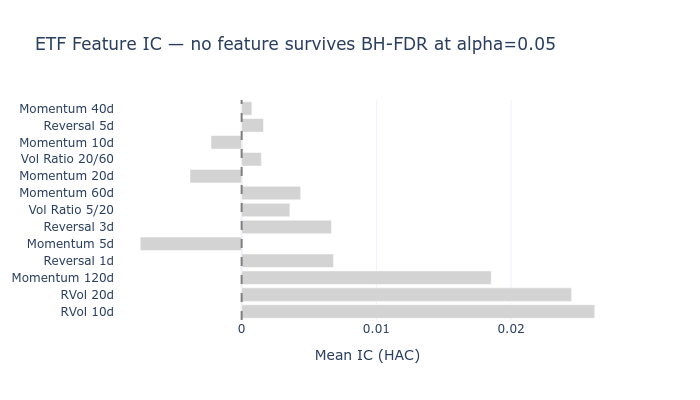

In [24]:
# IC by feature, colored by BH-FDR significance
sort_idx = np.argsort(etf_p)
sorted_names = [etf_test_results[i]["feature"] for i in sort_idx]
sorted_ics = [etf_test_results[i]["ic"] for i in sort_idx]
sorted_bh = [bool(etf_bh["rejected"][i]) for i in sort_idx]
colors_etf = ["#2166ac" if b else "lightgray" for b in sorted_bh]

fig = go.Figure(
    go.Bar(
        y=sorted_names,
        x=sorted_ics,
        orientation="h",
        marker_color=colors_etf,
    )
)
fig.add_vline(x=0, line_dash="dash", line_color="gray")
fig.update_layout(
    title="ETF Feature IC — no feature survives BH-FDR at alpha=0.05",
    xaxis_title="Mean IC (HAC)",
    height=400,
    template="plotly_white",
)
fig.show()

The Rademacher ratio is well below 100%, reflecting the high correlation
among momentum variants — testing 6 lookbacks is not 6 independent trials.
Even with this milder effective penalty, most features do not survive BH-FDR
correction after HAC inference.

With 13 correlated momentum/reversal/volatility/volume features and HAC
inference, no feature survives BH-FDR at $\alpha = 0.05$ in the present
scan. Univariate bivariate-IC screening is one filter; Chapters 11–12
evaluate the same features in a multivariate setting where the relevant
question is conditional contribution to a fitted model, not single-feature
significance. The corrections here ensure that features *selected* for
that pipeline have not been promoted purely by selection bias.

## 6. Output: Discovery Report

The JSON structure below is a template for production logging. Recording
the search-set size, correction method, and per-method discovery counts
alongside the Rademacher analysis makes the report self-contained and
auditable.

In [25]:
# Build structured output — base report with naive and Harvey thresholds
discovery_report = {
    "n_factors_tested": n_factors_zoo,
    "n_true_factors": n_true,
    "sample_periods": n_periods_zoo,
    "methods": {
        "naive_t2": {
            "threshold": "t > 2.0",
            "discoveries": int(naive_sig.height),
            "true_positives": int(naive_tp),
            "false_positives": int(naive_fp),
            "fdr": round(naive_fp / naive_sig.height, 3) if naive_sig.height > 0 else 0,
            "power": round(naive_tp / n_true, 3),
        },
        "harvey_t3": {
            "threshold": "t > 3.0",
            "discoveries": int(harvey_sig.height),
            "true_positives": int(harvey_tp),
            "false_positives": int(harvey_fp),
            "fdr": round(harvey_fp / harvey_sig.height, 3) if harvey_sig.height > 0 else 0,
            "power": round(harvey_tp / n_true, 3),
        },
    },
}

In [26]:
# Add FDR, Holm-Bonferroni, and Rademacher analysis
discovery_report["methods"]["bh_fdr"] = {
    "alpha": 0.05,
    "discoveries": int(np.sum(bh_significant)),
    "true_positives": int(bh_tp),
    "false_positives": int(bh_fp),
    "fdr": round(bh_fp / np.sum(bh_significant), 3) if np.sum(bh_significant) > 0 else 0,
    "power": round(bh_tp / n_true, 3),
}
discovery_report["methods"]["holm_bonferroni"] = {
    "alpha": 0.05,
    "discoveries": int(np.sum(holm_significant_zoo)),
    "true_positives": int(holm_tp),
    "false_positives": int(holm_fp),
    "fdr": round(holm_fp / np.sum(holm_significant_zoo), 3)
    if np.sum(holm_significant_zoo) > 0
    else 0,
    "power": round(holm_tp / n_true, 3),
}
discovery_report["rademacher_analysis"] = {
    "empirical_complexity": round(float(R_hat), 4),
    "massart_bound": round(float(massart_bound), 4),
    "complexity_ratio": round(float(R_hat / massart_bound), 3),
}

In [27]:
print(json.dumps(discovery_report, indent=2))

{
  "n_factors_tested": 300,
  "n_true_factors": 15,
  "sample_periods": 1260,
  "methods": {
    "naive_t2": {
      "threshold": "t > 2.0",
      "discoveries": 27,
      "true_positives": 15,
      "false_positives": 12,
      "fdr": 0.444,
      "power": 1.0
    },
    "harvey_t3": {
      "threshold": "t > 3.0",
      "discoveries": 16,
      "true_positives": 15,
      "false_positives": 1,
      "fdr": 0.062,
      "power": 1.0
    },
    "bh_fdr": {
      "alpha": 0.05,
      "discoveries": 15,
      "true_positives": 15,
      "false_positives": 0,
      "fdr": 0.0,
      "power": 1.0
    },
    "holm_bonferroni": {
      "alpha": 0.05,
      "discoveries": 12,
      "true_positives": 12,
      "false_positives": 0,
      "fdr": 0.0,
      "power": 0.8
    }
  },
  "rademacher_analysis": {
    "empirical_complexity": 0.1571,
    "massart_bound": 0.1912,
    "complexity_ratio": 0.822
  }
}


## 7. Deflated Sharpe Ratio (DSR)

When the outcome is a strategy Sharpe ratio (not factor IC), the **Deflated Sharpe
Ratio** (Bailey & López de Prado, 2014) adjusts for selection bias among
multiple strategies tested.

DSR answers: "Given that I tested N strategies and picked the best Sharpe,
what is the probability that this Sharpe is genuinely positive?"

$$DSR = P\left[\hat{SR} > E\left[\max_{k \in K} SR_k\right] \mid H_0\right]$$

In [28]:
# Simulate noise strategy return streams
rng_dsr = np.random.default_rng(99)
n_strategies = N_STRATEGIES_DSR
n_days = N_DAYS_DSR

strategy_returns = [rng_dsr.standard_normal(n_days) * 0.01 for _ in range(n_strategies)]

# Apply DSR to all strategies — picks best and adjusts
dsr_result = deflated_sharpe_ratio(strategy_returns, frequency="daily")

print(
    pl.DataFrame(
        {
            "metric": [
                "Strategies tested",
                "Sample (days)",
                "Best Sharpe (ann.)",
                "E[max] under null",
                "Deflated Sharpe",
                "DSR probability",
                "Significant (95%)",
            ],
            "value": [
                f"{n_strategies}",
                f"{n_days}",
                f"{dsr_result.sharpe_ratio_annualized:.2f}",
                f"{dsr_result.expected_max_sharpe:.2f}",
                f"{dsr_result.deflated_sharpe:.2f}",
                f"{dsr_result.probability:.1%}",
                f"{dsr_result.is_significant}",
            ],
        }
    )
)

shape: (7, 2)
┌────────────────────┬───────┐
│ metric             ┆ value │
│ ---                ┆ ---   │
│ str                ┆ str   │
╞════════════════════╪═══════╡
│ Strategies tested  ┆ 50    │
│ Sample (days)      ┆ 756   │
│ Best Sharpe (ann.) ┆ 1.30  │
│ E[max] under null  ┆ 0.08  │
│ Deflated Sharpe    ┆ 0.00  │
│ DSR probability    ┆ 60.0% │
│ Significant (95%)  ┆ False │
└────────────────────┴───────┘


The DSR correctly identifies that the best Sharpe among pure-noise strategies
is inflated by selection. The `expected_max_sharpe` quantifies how good the
best strategy would look *even if none had skill*.

## 8. Probability of Backtest Overfitting (PBO)

PBO (Bailey et al., 2017) estimates the probability that the best in-sample
strategy is worst out-of-sample. **PBO > 0.5 suggests severe overfitting.**

The method uses combinatorial purged cross-validation (CPCV): split the data
into S groups, choose half as in-sample, the rest as out-of-sample, and
repeat across all $\binom{S}{S/2}$ combinations.

Full implementation with CPCV splitting is covered in Chapter 16. Here we
demonstrate the `compute_pbo()` function on pre-computed IS/OOS performance.

In [29]:
# Simulate IS/OOS performance for strategies
rng_pbo = np.random.default_rng(77)
n_strat_pbo = N_STRAT_PBO
n_combos = N_COMBOS_PBO

# Under null: IS/OOS are independent noise
is_performance = rng_pbo.standard_normal((n_combos, n_strat_pbo))
oos_performance = rng_pbo.standard_normal((n_combos, n_strat_pbo))

# Add slight IS advantage to one strategy (overfitting)
is_performance[:, 0] += 1.5  # Looks great in-sample

pbo_result = compute_pbo(is_performance, oos_performance)

print(
    pl.DataFrame(
        {
            "metric": [
                "Strategies",
                "IS/OOS combinations",
                "PBO",
                "IS-best median OOS rank",
                "Degradation (mean +/- std)",
            ],
            "value": [
                f"{n_strat_pbo}",
                f"{n_combos}",
                f"{pbo_result.pbo:.1%}",
                f"{pbo_result.is_best_rank_oos_median:.1f} / {n_strat_pbo}",
                f"{pbo_result.degradation_mean:.2f} +/- {pbo_result.degradation_std:.2f}",
            ],
        }
    )
)

shape: (5, 2)
┌────────────────────────────┬───────────────┐
│ metric                     ┆ value         │
│ ---                        ┆ ---           │
│ str                        ┆ str           │
╞════════════════════════════╪═══════════════╡
│ Strategies                 ┆ 20            │
│ IS/OOS combinations        ┆ 50            │
│ PBO                        ┆ 42.0%         │
│ IS-best median OOS rank    ┆ 9.5 / 20      │
│ Degradation (mean +/- std) ┆ 2.10 +/- 1.03 │
└────────────────────────────┴───────────────┘


PBO is a powerful complement to DSR. While DSR focuses on Sharpe inflation,
PBO directly measures whether the in-sample best-performing configuration *degrades* out-of-sample.
See Chapter 16 for applying PBO with actual CPCV backtest splits.

## 9. Minimum Track Record Length (MinTRL)

How long must a track record be before we trust a Sharpe ratio?
`compute_min_trl()` gives the minimum number of observations needed for
statistical significance, adjusted for non-normal returns (skewness, kurtosis,
autocorrelation). `min_trl_fwer()` additionally adjusts for the number of
strategies tested.

In [30]:
# MinTRL table: varying Sharpe and number of strategies
sharpes = [0.5, 1.0, 1.5, 2.0]
n_trials_list = [1, 10, 100]

rows = []
for sr in sharpes:
    row = {"sharpe": sr}
    for n in n_trials_list:
        if n == 1:
            result = compute_min_trl(
                observed_sharpe=sr / np.sqrt(252),
                target_sharpe=0.0,
                frequency="daily",
            )
        else:
            result = min_trl_fwer(
                observed_sharpe=sr / np.sqrt(252),
                n_trials=n,
                variance_trials=0.0,
                target_sharpe=0.0,
                frequency="daily",
            )
        years = result.min_trl_years
        row[f"N={n}"] = "inf" if years == float("inf") else f"{years:.1f}y"
    rows.append(row)

mintrl_df = pl.DataFrame(rows)
display(mintrl_df)

sharpe,N=1,N=10,N=100
f64,str,str,str
0.5,"""10.8y""","""10.8y""","""10.8y"""
1.0,"""2.7y""","""2.7y""","""2.7y"""
1.5,"""1.2y""","""1.2y""","""1.2y"""
2.0,"""0.7y""","""0.7y""","""0.7y"""


**Interpretation**: A strategy with Sharpe 1.0 needs ~2.7 years of daily data
for significance. With `variance_trials=0` the FWER correction collapses to
the single-test case — all N columns are identical. In practice, when strategy
Sharpe ratios vary (`variance_trials > 0`), larger N increases the required
track record because the expected best-by-chance Sharpe grows with N.

This connects to NB06's track record planning for IC: both IC and Sharpe
require longer records than practitioners typically assume.

## 10. One-Call Production Alternative

`multiple_testing_summary()` wraps the manual HAC → BH/Holm pipeline into
a single call. Use it after you've computed per-factor test results.

In [31]:
# Build test results from the zoo simulation's pre-computed HAC statistics
test_results = [
    {
        "name": r["factor"],
        "p_value": r["p_value_hac"],
        "t_stat": r["t_stat_hac"],
    }
    for r in zoo_results
]

summary_bh = multiple_testing_summary(test_results, method="benjamini_hochberg", alpha=0.05)

summary_df = pl.DataFrame(
    {
        "metric": [
            "Tests",
            "Significant (uncorrected)",
            "Significant (BH-FDR)",
            "Correction method",
        ],
        "value": [
            str(summary_bh["n_tests"]),
            str(summary_bh["n_significant_uncorrected"]),
            str(summary_bh["n_significant_corrected"]),
            summary_bh["correction_method"],
        ],
    }
)
display(summary_df)

metric,value
str,str
"""Tests""","""300"""
"""Significant (uncorrected)""","""29"""
"""Significant (BH-FDR)""","""15"""
"""Correction method""","""benjamini_hochberg"""


## Summary

### Key Concepts

| Concept | Description |
|---------|-------------|
| **Selection Bias** | Best IC/Sharpe is inflated when testing many factors |
| **BH-FDR** | Controls expected proportion of false discoveries |
| **Holm-Bonferroni** | Controls probability of *any* false discovery (FWER) |
| **Rademacher Complexity** | Sharper bound for correlated hypotheses |
| **Deflated Sharpe Ratio** | Adjusts best Sharpe for selection among N strategies |
| **PBO** | Probability that the IS best-performing config degrades worst OOS (Ch16 deep dive) |
| **MinTRL** | Minimum track record for Sharpe significance |
| **Harvey Threshold** | t > 3.0 for factor discovery in published literature |

### When to Use What

| Situation | Tool |
|-----------|------|
| Screening many factors (IC) | BH-FDR or Holm-Bonferroni |
| Correlated factor variants | Rademacher (RAS) adjustment |
| Selecting best strategy (Sharpe) | Deflated Sharpe Ratio |
| Validating backtest results | PBO + DSR |
| Planning data collection | MinTRL |

### Next Notebooks

- [`08_causal_sanity_checks`](08_causal_sanity_checks.ipynb) - Causal falsification tests
- Chapter 8 notebooks for factor orthogonality and robustness analysis
- Chapter 16 for full PBO with CPCV backtest splits